# Задание «Предсказание карт внимания»

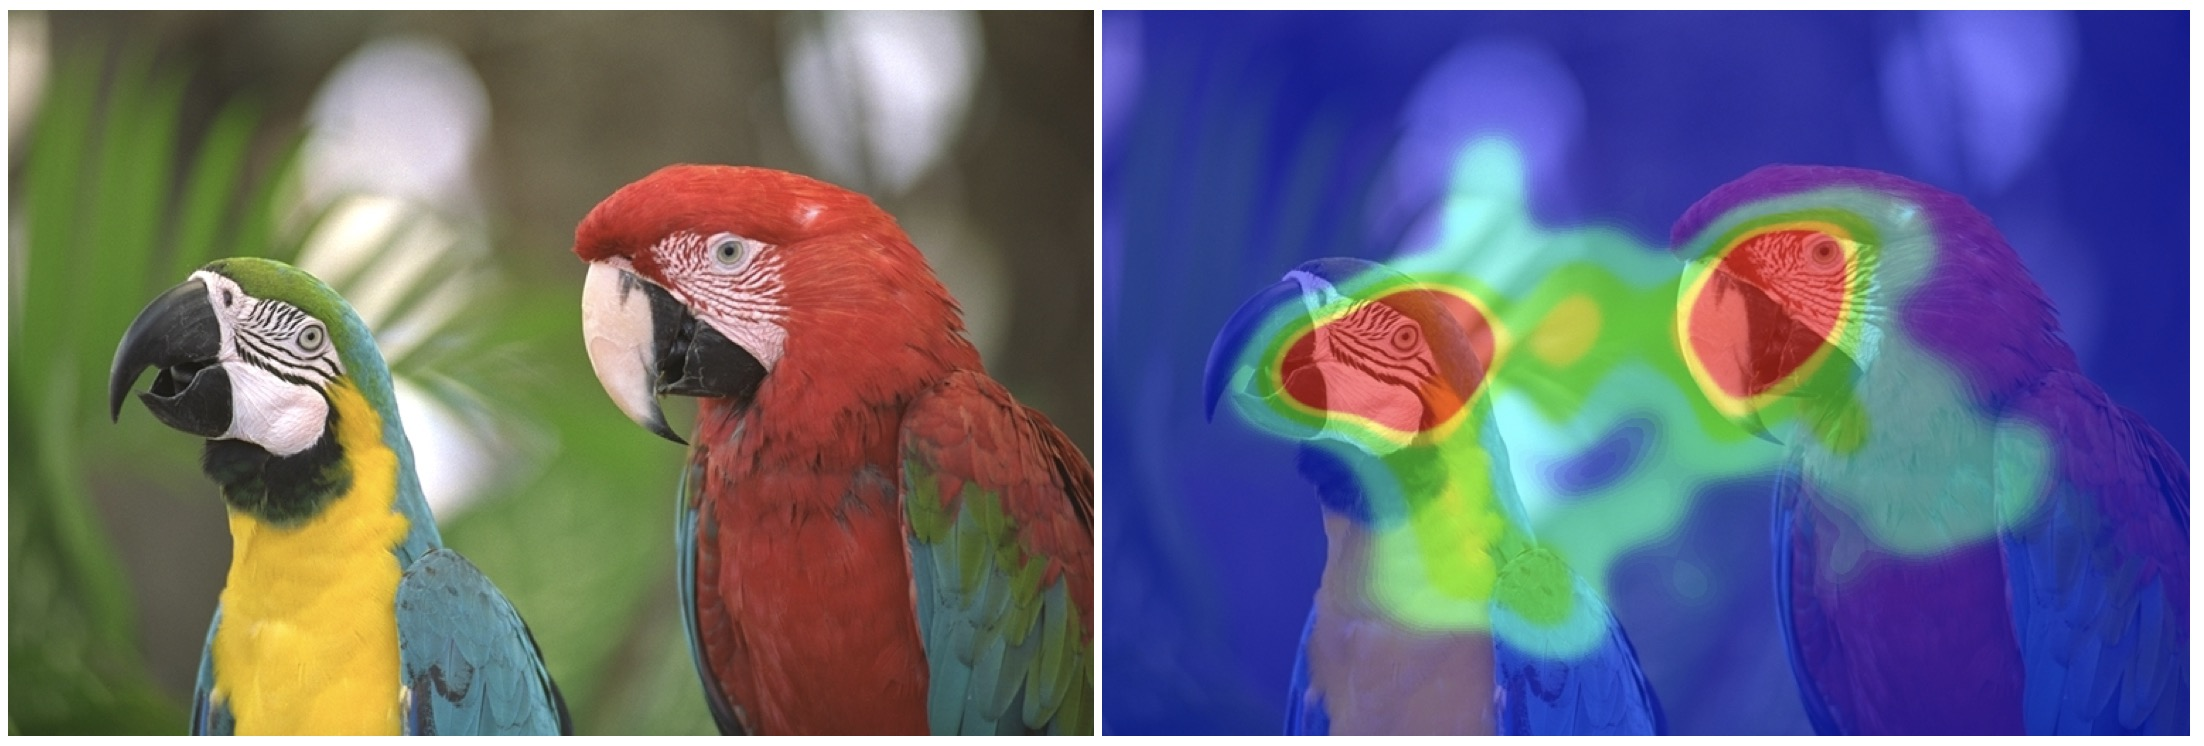

## Описание

Предлагается реализовать нейросетевой алгоритм построения карт внимания

**Требования**:
* Модель должна быть реализована на фреймворке PyTorch
* Для обучения разрешается использовать только обучащую выборку, внешние данные использовать нелья. Однако не запрещено (и, наоборот, приветствуется) использовать аугментации (размножение датасета) и transfer-learning (использование предобученной модели) с дообучением
* Обработка одного кадра должна быть возможна на видеокарте с объемом памяти 12Gb
* Соблюдать [кодекс чести](https://communitystandards.stanford.edu/policies-and-guidance/honor-code). Виновные будут найдены и наказаны

### Оценивание

1. Каждый участник может представить не более 1 алгоритма для финального тестирования  

2. Тестирование будет проводиться на закрытой тестовой выборке, содержащей <= 50 видео. В каждом видео > 200 кадров

3. В качестве метрик будут использованы:

    * Similarity score (SIM)
    * Pearson’s Correlation Coefficient (CC)
    * Normalized Scanpath Saliency (NSS)
    
    ([Подробнее про метрики](https://arxiv.org/pdf/1604.03605.pdf))
   При совпадении средних мест, при ранжировании будет учитываться приоритет метрик в указанном порядке

   
5. По итогам тестирования будет составлена общая таблица результатов по каждой из метрик

6. Место алгоритма определяется по формуле: 
$$ \text{Place}_{\text{algo}} = \frac{\text{Place}_{\text{SIM}} + \text{Place}_{\text{CC}} + \text{Place}_{\text{NSS}}}{3}$$

7. Баллы участника зависят от места его алгоритма: 
$$ \text{Score}_{\text{stud}} = \text{score}(\text{Place}_{\text{algo}}) $$

In [ ]:
!pip install torch==2.8.0 torchvision==0.23.0 torchcodec==0.7.0 opencv-python matplotlib torchinfo tqdm imageio

In [1]:
import os
import cv2
import tqdm
import torch
import imageio
import itertools
import torchvision
import numpy as np
from torch import nn
from torchinfo import summary
import matplotlib.pyplot as plt

#если ffmpeg не установлен в системе
#его можно поставить через conda-окружение
#!conda install ffmpeg -c conda-forge
from torchcodec.decoders import VideoDecoder
from torch.utils.data import Dataset, DataLoader
from utils import normalize_map, padding, padding_fixation

In [2]:
# Удостоверимся, что есть видеокарта
# !nvidia-smi -L
torch.cuda.is_available()
torch.backends.mps.is_available()

True

## 1. Подготовка данных

[Дублирование датасета со страницы задания на Google Диск для пользователей Colab [3.4 GB]](https://drive.google.com/file/d/1d4cNbtZ3nirpxR0P6LTnlWLdbNgJH8jG/view?usp=sharing)

### Датасеты и даталоадеры

Вы можете полностью менять эту реализацию, использовать более одного кадра, добавлять transforms и т.д.!

In [3]:
class DatasetClass(Dataset):
    def __init__(self, path_data, transforms=None, num_frames=1, mode='val'):
        self.input_path_data, self.gt_path_data = path_data
        self.num_frames = num_frames
        self.transforms = transforms
        self.mode = mode
        
        # FIX: Added condition "if not folder.startswith('.')" to filter out .DS_Store
        self.map_idx_to_video = [
            {'input': os.path.join(self.input_path_data, folder), 
             'gt': os.path.join(self.gt_path_data, folder)}
            for folder in sorted(os.listdir(self.input_path_data))
            if not folder.startswith('.')
        ]

    def __len__(self):
        return len(self.map_idx_to_video)

    def __getitem__(self, idx):
        
        vid_paths = self.map_idx_to_video[idx]
        
        # Ensure VideoDecoder is imported or defined before this
        decoder_video = VideoDecoder(os.path.join(vid_paths['input'], 'source.mp4'), device='cpu')
        decoder_saliency = VideoDecoder(os.path.join(vid_paths['gt'], 'saliency.mp4'), device='cpu')
        
        if self.mode == 'val':
            # Берем фиксированный кадр для валидации
            start_idx = 0
        else:
            start_idx = np.random.randint(0, decoder_video.metadata.num_frames - self.num_frames + 1)
        
        end_idx = start_idx + self.num_frames

        frames = decoder_video.get_frames_at(indices=list(range(start_idx, end_idx)))
        small_frames = []

        for frame in frames.data:
            small_frame = padding(frame.permute(1, 2, 0).numpy(),
                                  height=216, width=384).astype('float32') / 255.
            small_frames.append(self.transforms(small_frame))
        
        # Предсказываем карту внимания для последнего кадра в наборе из num_frames кадров 
        # Не забываем делать паддинг и нормализацию для единообразия
        saliency = decoder_saliency.get_frames_at(indices=[end_idx - 1])

        small_saliency = padding(normalize_map(saliency.data[0][0].numpy()),
                                       height=216, width=384)[np.newaxis].astype('float32')
        
        # Бейзлайн модель использует функцию потерь, основанную только на карте saliency
        # Но если понадобится, вы можете использовать и карты фиксаций
        fixation_paths = os.path.join(vid_paths['gt'], 'fixations')
        
        # Added extra check here just in case, though the main error was likely the folder iteration
        fixations = [x for x in sorted(os.listdir(fixation_paths)) if '.ipynb' not in x and not x.startswith('.')]
        
        small_fixations = padding_fixation(
                            cv2.imread(os.path.join(fixation_paths, fixations[end_idx - 1]), 
                            cv2.IMREAD_GRAYSCALE))[np.newaxis].astype('float32')
        
        return small_frames, small_saliency, small_fixations


# Бесконечное равномерное семплирование из датасета
class InfiniteSampler(torch.utils.data.sampler.Sampler):
    def __init__(self, size):
        self.size = size

    def _infinite_indices(self):
        g = torch.Generator()
        while True:
            yield from torch.randperm(self.size, generator=g)

    def __iter__(self):
        yield from itertools.islice(self._infinite_indices(), 0, None, 1)

In [4]:
# Нормализация параметрами из ImageNet
normalization = torchvision.transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])

denormalization = torchvision.transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225])

# Вы также можете попробовать использовать аугментации, но будьте аккуратны
# требуются преобразования, не меняющие области внимания, а также если вы используете
# несколько кадров, то пространственные преобразования между кадрами должны быть согласованы!
im_transform = torchvision.transforms.Compose([
                    torchvision.transforms.ToTensor(),
                    normalization
               ])

In [5]:
DATA_TRAIN = ['./public_tests/01_test_file_input/train/', 
              './public_tests/01_test_file_gt/train/']

DATA_VAL = ['./public_tests/01_test_file_input/test/', 
            './public_tests/01_test_file_gt/test/']

In [6]:
data_train = DatasetClass(DATA_TRAIN, transforms=im_transform, num_frames=1, mode='train')
data_valid = DatasetClass(DATA_VAL, transforms=im_transform, num_frames=1, mode='val')

# Число workers лучше ставить учитывая число ядер CPU
train_loader = DataLoader(data_train, batch_size=12, sampler=InfiniteSampler(len(data_train)), 
                          num_workers=0, pin_memory=True)

valid_loader = DataLoader(data_valid, batch_size=1, shuffle=False, pin_memory=False)

Посмотрим на случайный пример из датасета

In [7]:
frames, saliency, fixations = next(iter(valid_loader))

In [ ]:
plt.imshow(denormalization(frames[0][0]).permute(1, 2, 0))

In [ ]:
plt.imshow(saliency[0][0], cmap='jet')

In [ ]:
plt.imshow(fixations[0][0])

## 2. Создадим класс нашей модели

Так как данных мало, предлагается использовать технику **transfer learning**, используя нейросеть, предобученную на сегментацию изображений, например, **Deeplabv3**. 

Модель построим из трех частей:
* Сверточный Encoder, например, ResNet50
* Пирамидальный пулинг ASPP состоящий из нескольких параллельных сверток с разным рецептивным полем благодаря dilation convolution
* Сверточный Decoder, получающий финальное предсказание

**Архитектура Deeplab**:

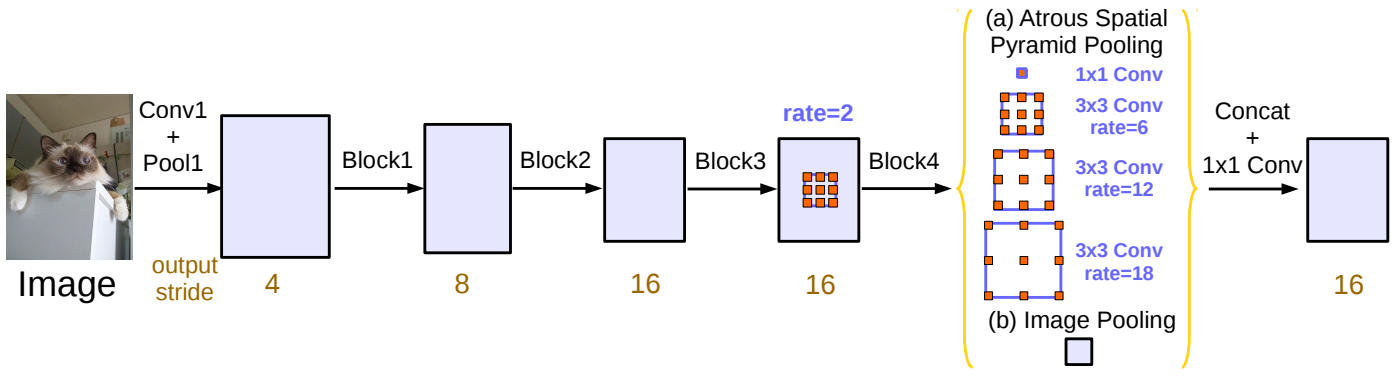

**Dilation convolution**:

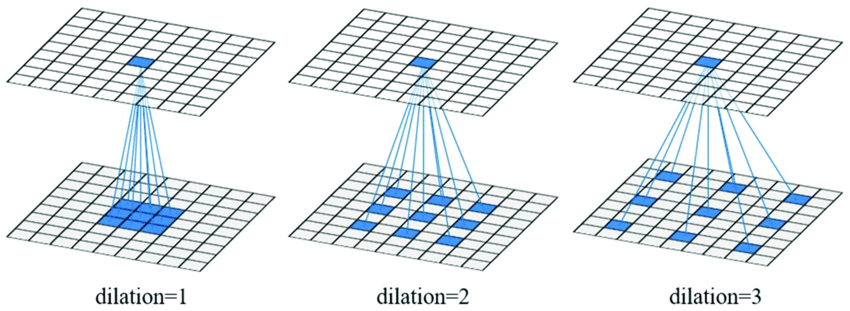

В моделе, доступной в библиотеке `torchvision.models`, Decoder получает изображение в низком разрешении и имеет 21 класс (количество выходных каналов):

In [7]:
torchvision.models.segmentation.deeplabv3_resnet50(
    weights=torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT).classifier[-1]

Conv2d(256, 21, kernel_size=(1, 1), stride=(1, 1))

В нашей же задаче требуется предсказания одноканального изображения с разрешением, как у исходного. Поэтому сделаем свой декодер, постепенно повышая разрешение в 2 раза. На последнем слое применим нормализацию в 0-1.

Документация PyTorch: https://pytorch.org/docs/stable/index.html
        
Ваша модель должна быть описана в файле `saliency.py`, этот файл **СДАЕТСЯ** в проверяющую систему!

Файл `saliency.py` должен быть самодостаточным, т.е. содержать все необходимые import-ы и функции для создания и запуска модели.

In [8]:
from saliency import SaliencyModel

In [9]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [10]:
model = SaliencyModel().to(device)

In [11]:
summary(model, input_size=(8, 3, 216, 384))

Layer (type:depth-idx)                             Output Shape              Param #
SaliencyModel                                      [8, 1, 216, 384]          --
├─IntermediateLayerGetter: 1-1                     [8, 960, 14, 24]          --
│    └─Conv2dNormActivation: 2-1                   [8, 16, 108, 192]         --
│    │    └─Conv2d: 3-1                            [8, 16, 108, 192]         432
│    │    └─BatchNorm2d: 3-2                       [8, 16, 108, 192]         32
│    │    └─Hardswish: 3-3                         [8, 16, 108, 192]         --
│    └─InvertedResidual: 2-2                       [8, 16, 108, 192]         --
│    │    └─Sequential: 3-4                        [8, 16, 108, 192]         464
│    └─InvertedResidual: 2-3                       [8, 24, 54, 96]           --
│    │    └─Sequential: 3-5                        [8, 24, 54, 96]           3,440
│    └─InvertedResidual: 2-4                       [8, 24, 54, 96]           --
│    │    └─Sequential: 3-6   

## 3. Зададим функцию потерь

Будем использовать дивергенцию [Кульбака-Лейблера](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence), сравнивая предсказанное распределение с эталонной картой внимания. Вы так же можете использовать другие функции потерь при обучении.

In [12]:
def kld(y_pred, y_true, eps=1e-7):
    """This function computes the Kullback-Leibler divergence between ground
       truth saliency maps and their predictions. Values are first divided by
       their sum for each image to yield a distribution that adds to 1.
    Args:
        y_true (tensor, float32): A 4d tensor that holds the ground truth
                                  saliency maps with values between 0 and 255.
        y_pred (tensor, float32): A 4d tensor that holds the predicted saliency
                                  maps with values between 0 and 1.
        eps (scalar, float, optional): A small factor to avoid numerical
                                       instabilities. Defaults to 1e-7.
    Returns:
        tensor, float32: A 0D tensor that holds the averaged error.
    """

    sum_true = torch.sum(y_true, dim=(1, 2, 3), keepdim=True)
    y_true = y_true / (eps + sum_true)

    sum_pred = torch.sum(y_pred, dim=(1, 2, 3), keepdim=True)
    y_pred = y_pred / (eps + sum_pred)
    
    loss = y_true * torch.log(eps + y_true / (eps + y_pred))
    loss = torch.mean(torch.sum(loss, dim=(1, 2, 3)))

    return loss

## 4. Обучим модель

__Пайплайн обучения__:
* Определить __таргет__. В нашей задаче это эталонная карта внимания
* Определить __функцию потерь (loss)__. Используем KLD из предыдущего этапа
* Выбрать __оптимизатор__. Чтобы всё быстро заработало, возьмем `Adam/AdamW` c [lr=3e-4](https://www.urbandictionary.com/define.php?term=Karpathy%20Constant)

In [13]:
# Берем оптимизатор AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Рекомендуется увеличить следующие значения т.к.
# они выбраны для демонстрации, а не качества модели
model = model.to(device)
# Число эпох
NUM_EPOCHS = 5
# Делаем 100 случайных семплирований из датасета на эпоху
NUM_STEPS = 200

In [19]:
for epoch in range(NUM_EPOCHS):
    train_losses = []
    valid_losses = []

    # Часть слоев сети имеет два режима - train и eval
    # Важно переводить из одного в другой при обучении/тестировании
    model.train()

    ##################
    ### TRAIN LOOP ###
    ##################
    loop = tqdm.tqdm(itertools.islice(train_loader, NUM_STEPS), total=NUM_STEPS)
    for frames, saliency, _ in loop:
        # Set to zero the parameter gradients for the current batch
        optimizer.zero_grad()

        # Prediction for one frame
        frames = frames[0].to(device)
        saliency = saliency.to(device)
        pred_saliency = model(frames)

        # Calculate loss, make backward pass and update the parameters
        loss = kld(pred_saliency, saliency)
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        loop.set_postfix(loss=loss_value)
        train_losses.append(loss_value)
    

    #######################
    ### VALIDATION LOOP ###
    #######################
    with torch.no_grad():
        model.eval()
        for frames, saliency, _ in tqdm.tqdm(valid_loader, total=len(valid_loader)):
            optimizer.zero_grad()
            frames = frames[0].to(device)
            saliency = saliency.to(device)
            pred_saliency = model(frames)
            loss = kld(pred_saliency, saliency)
            valid_losses.append(loss.item())
        print("| Epoch: ", epoch, 
              "| Val Loss: ", np.mean(valid_losses), 
              "| Train Loss: ", np.mean(train_losses))

/Users/bigmilk/Desktop/vatolin/saliency/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 200/200 [00:05<00:00, 33.67it/s]


| Epoch:  0 | Val Loss:  0.4849925696849823 | Train Loss:  0.7556994439661503


100%|██████████| 200/200 [00:05<00:00, 35.03it/s]


| Epoch:  1 | Val Loss:  0.38571355313062666 | Train Loss:  0.6029460793733596


100%|██████████| 200/200 [00:05<00:00, 34.99it/s]


| Epoch:  2 | Val Loss:  0.35689863704144953 | Train Loss:  0.5846539399027825


100%|██████████| 200/200 [00:05<00:00, 34.90it/s]


| Epoch:  3 | Val Loss:  0.4866708777844906 | Train Loss:  0.555471610724926


100%|██████████| 200/200 [00:05<00:00, 35.06it/s]

| Epoch:  4 | Val Loss:  0.39091372314840556 | Train Loss:  0.5469605217874051


## 5. Протестируем модель

Сохраняем веса модели (этот файл **СДАЕТСЯ** в проверяющую систему)

In [20]:
torch.save(model, 'saliency.pth')

В качестве метрик будут использованы:
* Similarity score (SIM)
* Pearson’s Correlation Coefficient (CC)
* Normalized Scanpath Saliency (NSS)

[Подробнее про метрики](https://arxiv.org/pdf/1604.03605.pdf)

In [14]:
def similarity(s_map, gt):
    s_map = s_map / (np.sum(s_map) + 1e-7)
    gt = gt / (np.sum(gt) + 1e-7)
    return np.sum(np.minimum(s_map, gt))

In [15]:
def cc(s_map, gt):
    a = (s_map - np.mean(s_map))/(np.std(s_map) + 1e-7)
    b = (gt - np.mean(gt))/(np.std(gt) + 1e-7)
    r = (a*b).sum() / np.sqrt((a*a).sum() * (b*b).sum() + 1e-7)
    return r

In [16]:
def nss(s_map, gt):
    x,y = np.where(gt)
    s_map_norm = (s_map - np.mean(s_map))/(np.std(s_map) + 1e-7)
    temp = []
    for i in zip(x,y):
        temp.append(s_map_norm[i[0], i[1]])
    return np.mean(temp)

Помимо описания класса модели в **СДАВАЕМОМ** файле `saliency.py` необходимо описать класс `evaluate`, выполняющий логику загрузки модели и инференса на заданном видео с сохранением предсказаний.

Функция принимает путь до входных последовательностей кадров и путь до выходной папки предсказаний.

В этой функции нужно описать процесс загрузки весов модели получение карт внимания для всех входных видеопоследовательностей. Если ваша модель использует более одного кадра или требует дополнительных преобразований входа, реализуйте их внутри этой функции.

In [17]:
import os
from saliency import SaliencyEvaluator
from utils import NUM_TEST_VIDS

# Делаем предсказания моделью для всех входных кадров видео
evaluator = SaliencyEvaluator(model_path='saliency.pth')

for video_name in tqdm.tqdm(sorted(os.listdir(DATA_VAL[0]))[:NUM_TEST_VIDS]):

    video_path = os.path.join(DATA_VAL[0], video_name, 'source.mp4')
    output_saliency_path = os.path.join('./outputs', video_name)
    os.makedirs(output_saliency_path, exist_ok=True)

    evaluator.evaluate(video_path, output_saliency_path)

Evaluator using device: mps


100%|██████████| 40/40 [02:41<00:00,  4.04s/it]


In [18]:
# Функция вычисления тестовых метрик
from utils import calculate_metrics

In [19]:
import os

# Settings
NUM_TEST_VIDS = 40
test_output_path = './outputs/'
gt_path = DATA_VAL[1]

# Get the list of videos
video_list = sorted(os.listdir(gt_path))[:NUM_TEST_VIDS]

for video_name in video_list:
    pred_path = os.path.join(test_output_path, video_name)
    gt_fix_path = os.path.join(gt_path, video_name, 'fixations')
    
    # Get PNGs only
    pred_frames = set([x for x in os.listdir(pred_path) if '.png' in x])
    gt_frames = set([x for x in os.listdir(gt_fix_path) if '.png' in x])
    
    if pred_frames != gt_frames:
        print(f"❌ Mismatch found in video: {video_name}")
        print(f"   Prediction frames: {len(pred_frames)}")
        print(f"   GT frames:         {len(gt_frames)}")
        
        # Show a sample difference
        diff = list(pred_frames.symmetric_difference(gt_frames))
        print(f"   Difference examples: {diff[:5]}")
        break
else:
    print("✅ All video frames match!")

✅ All video frames match!


In [22]:
import os

def clean_hidden(path):
    # Removes .DS_Store and .ipynb_checkpoints
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.startswith('.'): os.remove(os.path.join(root, f))
        for d in dirs:
            if d.startswith('.'): import shutil; shutil.rmtree(os.path.join(root, d))

# 1. Clean both directories
print("Cleaning hidden files...")
clean_hidden('./outputs/')
clean_hidden(DATA_VAL[1]) 

# 2. Compare lists
preds = sorted(os.listdir('./outputs/'))[:40]
gts = sorted(os.listdir(DATA_VAL[1]))[:40]

if preds == gts:
    print("✅ Folders match! Run calculate_metrics() now.")
else:
    print(f"❌ Mismatch! Output: {len(preds)}, GT: {len(gts)}")
    print("Missing in Output:", set(gts) - set(preds))
    print("Extra in Output:", set(preds) - set(gts))

Cleaning hidden files...
✅ Folders match! Run calculate_metrics() now.


In [23]:
calculate_metrics('./outputs/', DATA_VAL[1])

100%|██████████| 300/300 [00:02<00:00, 141.20it/s]


{'cc': np.float64(0.6781243500683342),
 'cc_std': np.float64(0.123949621322255),
 'sim': np.float64(0.5931332499362039),
 'sim_std': np.float64(0.08080480234298447),
 'nss': np.float64(1.9123950150501556),
 'nss_std': np.float64(0.5365178120022811)}

In [ ]:
# Аналогичный вызов, которым будет тестироваться ваша модель в проверочной системе
!python3 run.py './public_tests/'

100%|█████████████████████████████████████████| 300/300 [00:03<00:00, 87.46it/s]
01 159.63s Ok, SIM: 0.6045±0.0800, CC: 0.6967±0.1302, NSS: 1.9336±0.5472
Mark: 2 SIM: 0.6045±0.0800, CC: 0.6967±0.1302, NSS: 1.9336±0.5472


In [24]:
# Сделаем анимацию полученной карты внимания
def gif_creator(video_path, predictions_path, gif_name='out.gif'):

    with imageio.get_writer(gif_name, mode="I") as writer:

        # Берем каждый 3ий кадр для ускорения
        cap = cv2.VideoCapture(os.path.join(video_path, 'source.mp4'))
        
        for input_name in tqdm.tqdm(sorted(os.listdir(predictions_path))):

            if '.png' not in input_name:
                continue

            pred_sm = cv2.imread(os.path.join(predictions_path, input_name), 0)
            _, frame = cap.read()

            # Invertion for colormap
            norm_sm = ((1 - padding(normalize_map(pred_sm), 
                                    height=frame.shape[0], width=frame.shape[1])) * 255).astype(np.uint8)
            heatmap = cv2.applyColorMap(norm_sm, cv2.COLORMAP_JET)
            
            alpha = 0.7
            alpha_blended = np.clip(alpha * frame + (1 - alpha) * heatmap, 0, 255).astype(np.uint8)
            
            writer.append_data(alpha_blended)

        cap.release()

In [25]:
gif_creator(video_path=os.path.join(DATA_VAL[0], '0001'),
            predictions_path=os.path.join('./outputs/0001/'))

100%|██████████| 301/301 [00:01<00:00, 247.40it/s]


In [ ]:
from IPython.display import Image

Image(open('out.gif','rb').read())

## 6. Дальнейшие шаги

Для улучшения качества вашей модели можно попробовать следующие этапы:
* Сделать более информативную валидацию, например, добавив подсчет тестовых метрик прямо в validation loop и используя все видео
* Попробовать обучать большее число эпох/шагов
* Исследовать регуляризацию, например, через Dropout
* Добавить skip-connection в Encoder-Decoder
* Сделать аугментации ([albumentations](https://github.com/albumentations-team/albumentations)). Будьте аккуранты с преобразованиями, которые могут потенциально изменить эталонные карты внимания. Начать можно с горизонтальных отражений
* Попробовать другие архитектуры, функции потерь и стратегии обучения
* Использовать информацию из более чем одного кадра (3D Conv/LSTM/GRU/любой другой способ агрегации). Обратите внимание: даже если ваш метод требует окно из кадров, тестирование всё равно будет учитывать все кадры видео. Во время тестирования вы можете искуственно дублировать первый кадр для накопления нужной ширины окна для предсказания.
* Поискать методы, решающие похожие задачи
* Пофантазировать и вдохновиться